# Reconstructing the past: estimating solar radio flux F10.7 from sunspot records
# Ilya Niafiodau, Vlad Zagorodnyuk, Zhanar Sirgebayeva, Skoltech, 2026

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

In [9]:
flux_year, flux_month, flux = np.loadtxt("Radio_flux_monthly_mean.txt", unpack=True)
sunspot_year, sunspot_month, sunspot = np.loadtxt("Sunspot_number_monthly_mean.txt", unpack=True)

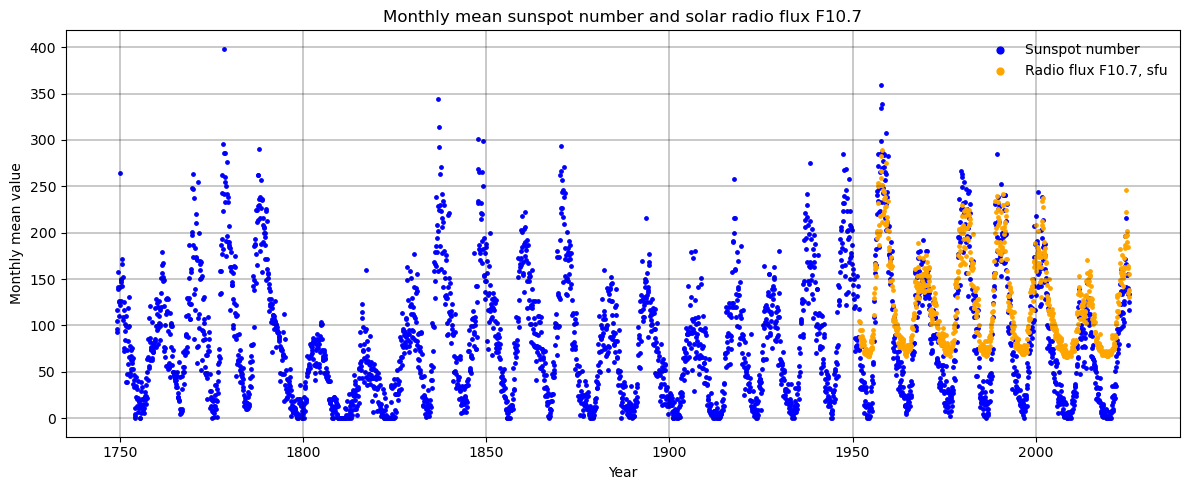

In [ ]:
flux_time = flux_year + (flux_month - 1) / 12
sunspot_time = sunspot_year + (sunspot_month - 1) / 12

fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(sunspot_time, sunspot, s=6, color="blue", label="Sunspot number")
ax.scatter(flux_time, flux, s=6, color="orange", label="Radio flux F10.7, sfu")

ax.set_title("Monthly mean sunspot number and solar radio flux F10.7")
ax.set_xlabel("Year")
ax.set_ylabel("Monthly mean value")
ax.grid(True, color="black", linewidth=0.3)
ax.legend(frameon=False, markerscale=2)

fig.tight_layout()
plt.show()

In [14]:
def smooth(data, time):
    n = len(time)
    smoothed = data
    for i in range(6, n-6):
        sum = data[i-6] / 24 
        for j in range(i-5, i+6):
            sum += 1 / 12 * data[j]
        sum += data[i+6] / 24
        smoothed[j] = sum
    return smoothed

sunspot_smoothed = smooth(sunspot, sunspot_time)
flux_smoothed = smooth(flux, flux_time)

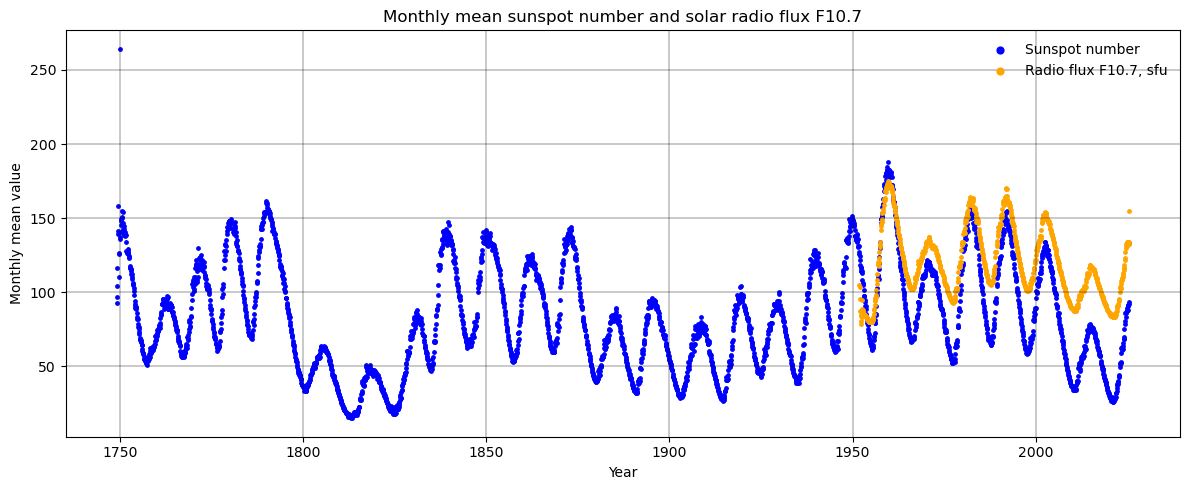

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(sunspot_time, sunspot_smoothed, s=6, color="blue", label="Sunspot number")
ax.scatter(flux_time, flux_smoothed, s=6, color="orange", label="Radio flux F10.7, sfu")

ax.set_title("Smoothed monthly mean sunspot number and solar radio flux F10.7")
ax.set_xlabel("Year")
ax.set_ylabel("Smoothed monthly mean value")
ax.grid(True, color="black", linewidth=0.3)
ax.legend(frameon=False, markerscale=2)

fig.tight_layout()
plt.show()